**Phân tích Hồi quy tuyến tính (Linear Regression) để đánh giá mối quan hệ giữa tỷ suất sinh lời của cổ phiếu MSN (tập đoàn Masan) và chỉ số thị trường VN30.**

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [3]:
data_set = pd.read_excel(r"C:\Users\anhki\OneDrive\Documents\cfa\MSN QUAN1.xlsx")

In [4]:
data_set.head(10)

,DATE,MSN,VN30
0,20/11/2022,-0.0126,-0.0038
1,13/11/2022,0.1006,0.0235
2,06/11/2022,0.0261,-0.0492
3,30/10/2022,0.0048,-0.0307
4,23/10/2022,0.1217,0.0187
5,16/10/2022,-0.0532,-0.0479
6,09/10/2022,-0.0307,0.0210
7,02/10/2022,-0.1768,-0.0976
8,25/09/2022,-0.0884,-0.0522
9,18/09/2022,-0.0372,-0.0298


In [5]:
# Chỉnh sửa lại định dạng ngày/tháng
data_set["Date2"]=pd.to_datetime(data_set["DATE"],format="%d/%m/%Y")

In [6]:
print(data_set.head())

         DATE     MSN    VN30      Date2
0  20/11/2022 -0.0126 -0.0038 2022-11-20
1  13/11/2022  0.1006  0.0235 2022-11-13
2  06/11/2022  0.0261 -0.0492 2022-11-06
3  30/10/2022  0.0048 -0.0307 2022-10-30
4  23/10/2022  0.1217  0.0187 2022-10-23


In [9]:
# Chọn dữ liệu để phân tích, sử dụng index là Date2 nhằm mục đích sử dụng time series (nếu cần)
data=data_set.loc[:,["Date2","VN30","MSN"]].set_index("Date2")

In [8]:
# Chọn dữ liệu để phân tích, sử dụng index là Date2 nhằm mục đích sử dụng time series (nếu cần)
data=data_set.loc[:,["Date2","VN30","MSN"]].set_index("Date2")

In [10]:
print(data.head())

              VN30     MSN
Date2                     
2022-11-20 -0.0038 -0.0126
2022-11-13  0.0235  0.1006
2022-11-06 -0.0492  0.0261
2022-10-30 -0.0307  0.0048
2022-10-23  0.0187  0.1217


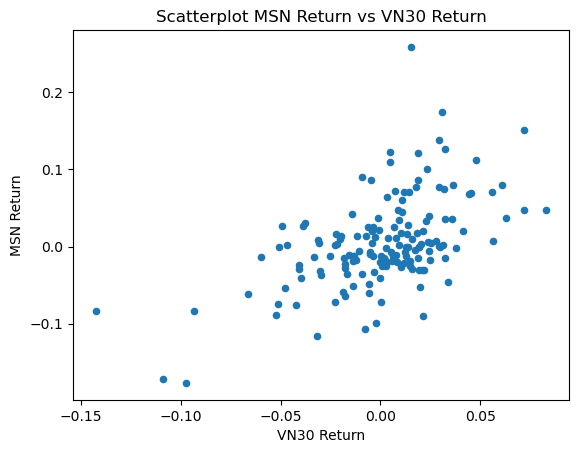

In [11]:
# Mô tả các giá trị của 2 biến dưới dạng scatter plot
scatt = data.plot.scatter(
    x="VN30",
    y="MSN",
    title="Scatterplot MSN Return vs VN30 Return",
)
scatt.set(xlabel="VN30 Return", ylabel="MSN Return")
plt.show()

Biểu đồ phân tán (Scatter plot) giữa tỷ suất sinh lời của MSN và chỉ số VN30 cho thấy một xu hướng phân bổ các điểm dữ liệu dọc theo một đường thẳng hướng lên. Điều này minh chứng cho sự tồn tại của một mối tương quan thuận (positive correlation) rõ rệt: khi thị trường chung tăng trưởng, giá cổ phiếu MSN có xu hướng biến động cùng chiều. Độ dốc của đường hồi quy trong biểu đồ này chính là hình ảnh trực quan của Hệ số Beta (Beta coefficient), phản ánh mức độ phản ứng của cổ phiếu trước các cú sốc thị trường.

In [12]:
# Mô tả dữ liệu của các biến
print(data.describe())

             VN30         MSN
count  156.000000  156.000000
mean     0.001056    0.004883
std      0.032582    0.058815
min     -0.142700   -0.176800
25%     -0.013875   -0.023650
50%      0.004900   -0.000450
75%      0.019475    0.028325
max      0.083200    0.258800


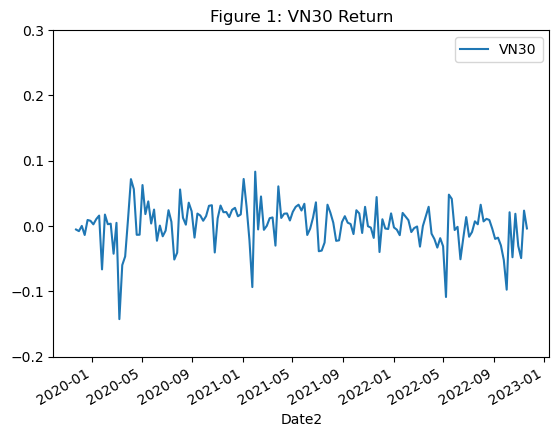

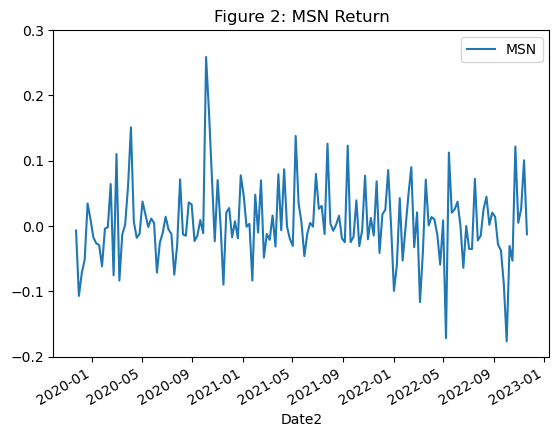

In [13]:
# Vẽ đồ thị mô tả dữ liệu của các biến
ax1 = data.plot(y="VN30", title="Figure 1: VN30 Return")
ax2 = data.plot(y="MSN", title="Figure 2: MSN Return")
ax1.set_ylim(-0.2, 0.3)
ax2.set_ylim(-0.2, 0.3);

Về tổng thể, cả hai chuỗi dữ liệu đều thể hiện tính dừng (stationarity), với các giá trị tỷ suất sinh lời dao động liên tục xung quanh mức giá trị trung bình bằng 0. Tuy nhiên, khi xét về độ biến động (volatility), có sự khác biệt rõ rệt giữa một chỉ số thị trường và một cổ phiếu riêng lẻ. Chỉ số VN30 tại Hình 1 cho thấy biên độ dao động tương đối hẹp, phần lớn các giá trị nằm trong khoảng từ $-0,1$ đến $0,1$. Điều này phản ánh tác động của việc đa dạng hóa danh mục đầu tư, giúp giảm bớt các cú sốc cực đoan từ các mã cổ phiếu thành phần. Ngược lại, tại Hình 2, cổ phiếu MSN thể hiện mức độ rủi ro đặc thù (idiosyncratic risk) cao hơn với các biến động mạnh và dày đặc hơn; nhiều thời điểm tỷ suất sinh lời của mã này đã vượt ngưỡng $0,1$ hoặc giảm sâu xuống dưới $-0,1$, tiêu biểu như đợt tăng trưởng mạnh vào cuối năm 2020. Sự tương quan giữa hai biểu đồ cũng cho thấy cổ phiếu MSN thường có xu hướng biến động cùng chiều với chỉ số VN30 trong những giai đoạn thị trường chung có biến cố lớn (như giai đoạn đầu đại dịch năm 2020 hoặc đợt điều chỉnh giữa năm 2022), nhưng vẫn duy trì những nét đặc trưng riêng về biên độ lợi nhuận và rủi ro.

In [14]:
# Tạo bảng covariance của 2 biến
print(data.cov())

          VN30       MSN
VN30  0.001062  0.001052
MSN   0.001052  0.003459


In [15]:
# Tạo bảng correlation của 2 biến
print(data.corr())

          VN30       MSN
VN30  1.000000  0.549039
MSN   0.549039  1.000000


In [16]:
# Mô hình hồi quy đơn OLS
result = smf.ols("MSN ~ VN30", data=data).fit()
print(result.summary())

                            OLS Regression Results                            
Dep. Variable:                    MSN   R-squared:                       0.301
Model:                            OLS   Adj. R-squared:                  0.297
Method:                 Least Squares   F-statistic:                     66.45
Date:                Mon, 09 Mar 2026   Prob (F-statistic):           1.16e-13
Time:                        10:51:39   Log-Likelihood:                 249.13
No. Observations:                 156   AIC:                            -494.3
Df Residuals:                     154   BIC:                            -488.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0038      0.004      0.971      0.3

In [17]:
print(result.summary2().tables[1])

              Coef.  Std.Err.         t         P>|t|    [0.025    0.975]
Intercept  0.003837  0.003951  0.971235  3.329542e-01 -0.003967  0.011641
VN30       0.991085  0.121576  8.151970  1.161871e-13  0.750913  1.231258


Mô hình hồi quy tuyến tính bằng phương pháp Bình phương tối thiểu thông thường (Ordinary Least Squares - OLS) đã được thực hiện với biến phụ thuộc là tỷ suất sinh lời của MSN và biến độc lập là tỷ suất sinh lời của chỉ số VN30. Kết quả ước lượng cho thấy hệ số chặn (Intercept) đạt giá trị $0,0038$ nhưng không có ý nghĩa thống kê (do giá trị p-value đạt $0,333$, lớn hơn mức ý nghĩa $0,05$), cho thấy khi thị trường đứng yên, tỷ suất sinh lời kỳ vọng của MSN không khác biệt đáng kể so với mức $0$. Ngược lại, hệ số góc của biến VN30 (thường được gọi là hệ số Beta) đạt $0,9911$ với giá trị p-value xấp xỉ bằng $0$, khẳng định mối quan hệ cùng chiều và có ý nghĩa thống kê rất cao giữa chỉ số VN30 và cổ phiếu MSN. Với hệ số Beta xấp xỉ bằng $1$, cổ phiếu MSN thể hiện mức độ rủi ro hệ thống tương đương với biến động chung của nhóm 30 cổ phiếu dẫn đầu; cụ thể, khi chỉ số VN30 biến động $1\%$, tỷ suất sinh lời của MSN có xu hướng biến động cùng chiều khoảng $0,99\%$.  
Về chất lượng mô hình, Hệ số xác định (R-squared) đạt giá trị $0,301$, cho biết biến độc lập VN30 giải thích được khoảng $30,1\%$ sự biến thiên của tỷ suất sinh lời cổ phiếu MSN. Mặc dù phần lớn biến động của MSN vẫn đến từ các yếu tố rủi ro đặc thù, nhưng kiểm định F (F-statistic) với giá trị xác suất (Prob (F-statistic)) cực nhỏ ($1,16 \times 10^{-13}$) xác nhận rằng mô hình hồi quy tổng thể là phù hợp và có ý nghĩa. Tuy nhiên, kết quả kiểm định Jarque-Bera (JB) có giá trị xác suất xấp xỉ bằng $0$, cho thấy phần dư của mô hình không tuân theo Phân phối chuẩn (Normal Distribution) — một đặc điểm thường gặp trong dữ liệu tài chính do hiện tượng "đuôi béo". Trong khi đó, chỉ số Durbin-Watson đạt $1,713$, nằm trong khoảng chấp nhận được để kết luận rằng hiện tượng Tự tương quan (Autocorrelation) bậc nhất không gây ảnh hưởng nghiêm trọng đến tính hiệu quả của các ước lượng trong mô hình này.

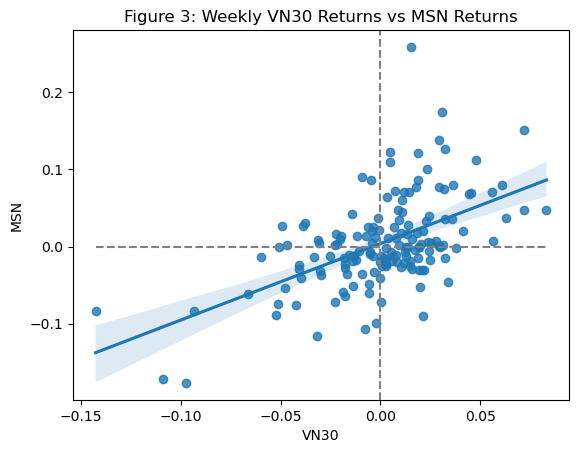

In [18]:
chart = sns.regplot(x="VN30", y="MSN", data=data).set(
title="Figure 3: Weekly VN30 Returns vs MSN Returns")
plt.axvline(0, 0, 1, dash_capstyle="butt", linestyle="--", color="grey")
plt.plot([min(data.VN30), max(data.VN30)], [0, 0], linestyle="--", color="grey")

Hình 3 minh họa mối quan hệ giữa tỷ suất sinh lời của chỉ số VN30 và cổ phiếu MSN thông qua Biểu đồ phân tán (Scatter plot) cùng với Đường hồi quy (Regression Line). Các điểm dữ liệu tập trung chủ yếu quanh đường hồi quy có độ dốc dương, xác nhận một cách trực quan mối tương quan thuận giữa biến động của thị trường và cổ phiếu. Vùng bóng mờ xung quanh đường hồi quy đại diện cho Khoảng tin cậy (Confidence Interval) $95\%$, cho thấy ước lượng về mối quan hệ này có độ chính xác khá cao dù vẫn tồn tại một số điểm dữ liệu ngoại lai (Outliers) có biến động cực đoan nằm xa đường thẳng.

In [19]:
influence = result.get_influence()
inf_sum = influence.summary_frame().sort_values("cooks_d", ascending=False)
print(inf_sum.head(10))

            dfb_Intercept  dfb_VN30   cooks_d  standard_resid  hat_diag  \
Date2                                                                     
2022-10-02      -0.161195  0.445882  0.108668       -1.760050  0.065559   
2020-03-08       0.115594 -0.447528  0.104990        1.175068  0.131999   
2020-10-04       0.419501  0.184086  0.091484        4.885037  0.007609   
2022-05-08      -0.133164  0.406019  0.089012       -1.433256  0.079751   
2020-10-11       0.228831  0.216864  0.048952        2.860568  0.011823   
2020-04-05       0.119705  0.280764  0.047262        1.572360  0.036825   
2021-05-09       0.169478  0.151754  0.026113        2.141659  0.011258   
2020-11-15      -0.186661 -0.117622  0.024349       -2.335086  0.008852   
2022-11-06       0.124189 -0.183061  0.023580        1.456086  0.021759   
2022-03-06      -0.152434  0.148497  0.021601       -1.818815  0.012891   

            dffits_internal  student_resid    dffits  
Date2                                       

Kết quả thống kê 10 quan sát có ảnh hưởng lớn nhất cho thấy:  
- Các quan sát trọng yếu: Quan sát vào ngày 02/10/2022 và 08/03/2020 có chỉ số Khoảng cách Cook (Cook's Distance) cao nhất, lần lượt là $0,108$ và $0,104$.  Đây là những thời điểm thị trường chứng khoán Việt Nam trải qua các biến động cực đoan: giai đoạn tháng 03/2020 gắn liền với cú sốc tâm lý từ đại dịch COVID-19, trong khi tháng 10/2022 tương ứng với giai đoạn thắt chặt thanh khoản và sụt giảm mạnh của chỉ số VN-Index.  
 - Nhận diện giá trị ngoại lai (Outliers): Quan sát ngày 04/10/2020 ghi nhận giá trị Sai số sinh viên hóa (Studentized Residuals) lên tới $5,296$, vượt xa ngưỡng phổ biến là $\pm 3$. Điều này cho thấy tại thời điểm đó, tỷ suất sinh lời của MSN có sự biến động lệch nhịp rất lớn so với dự báo từ biến động của VN30, tạo ra một điểm ngoại lai đáng chú ý trong mô hình.  
 - Mức độ thay đổi hệ số (DFBETAS): Chỉ số DFBETAS của biến VN30 (dfb_VN30) tại các ngày biến động lớn này dao động từ $-0,447$ đến $0,445$. Điều này ngụ ý rằng nếu loại bỏ các quan sát này, hệ số Beta của mô hình có thể thay đổi đáng kể, phản ánh độ nhạy của mô hình đối với các giai đoạn khủng hoảng hoặc biến động bất thường của thị trường.

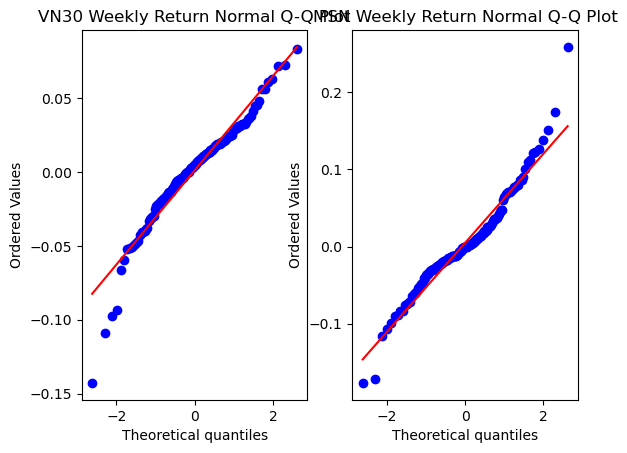

In [20]:
# Kiểm tra tính phân phối chuẩn của VN30 và HPG return bằng Q-Q plot
import pylab
import scipy.stats as stats
ax1 = plt.subplot(121)
stats.probplot(data["VN30"], dist="norm", plot=pylab)
plt.title("VN30 Weekly Return Normal Q-Q Plot")

ax2 = plt.subplot(122)
stats.probplot(data["MSN"], dist="norm", plot=pylab)
plt.title("MSN Weekly Return Normal Q-Q Plot")
pylab.show()

**Kiểm định tính phân phối chuẩn qua biểu đồ Q-Q Plot**  

Để làm rõ hơn các kết quả định lượng từ kiểm định Jarque-Bera (JB), nghiên cứu tiến hành quan sát biểu đồ Q-Q Plot (Quantile-Quantile Plot - Biểu đồ so sánh phân vị) cho cả hai chuỗi tỷ suất sinh lời của VN30 và MSN tại Hình trên. Về mặt lý thuyết, nếu dữ liệu tuân theo Phân phối chuẩn (Normal Distribution), các điểm quan sát màu xanh phải nằm sát hoặc trùng khớp với đường thẳng tham chiếu màu đỏ.  
Tuy nhiên, kết quả trực quan cho thấy những độ lệch đáng kể:  
- **Đối với chỉ số VN30**: Các điểm dữ liệu có xu hướng tách rời khỏi đường thẳng ở cả hai đầu, đặc biệt là ở phần đuôi dưới (phía bên trái biểu đồ). Điều này phản ánh sự hiện diện của các mức sụt giảm mạnh bất thường, vượt quá xác suất dự báo của một phân phối chuẩn thông thường.  
- **Đối với cổ phiếu MSN**: Biểu đồ thể hiện sự chệch hướng rõ rệt hơn, tạo thành hình dáng hơi cong ở hai đầu. Đặc biệt, sự xuất hiện của các điểm nằm xa đường tham chiếu ở phần đuôi trên cho thấy cổ phiếu này thường xuyên có những đợt tăng giá đột biến (hiện tượng "đuôi béo" - Fat tails).  
Sự hội tụ của các bằng chứng từ biểu đồ Q-Q Plot và giá trị thống kê Jarque-Bera (JB) đạt mức $85,572$ ($p < 0,05$) trong bảng hồi quy cho phép kết luận rằng cả hai chuỗi dữ liệu đều không tuân theo phân phối chuẩn. Trong bối cảnh phân tích tài chính, việc dữ liệu có hiện tượng đuôi béo và độ nhọn cao (Kurtosis đạt $6,043$) ngụ ý rằng các mô hình quản trị rủi ro truyền thống dựa trên giả định chuẩn có thể đánh giá thấp xác suất xảy ra của các sự kiện cực đoan trên thị trường.

In [28]:
# Shapiro Wilk Tests để kiểm tra tính phân phối chuẩn
shapiro_testVN30 = stats.shapiro(data["VN30"])
print("VN30")
print("Shapiro W: {0} \nShapiro pvalue {1}".format(shapiro_testVN30.statistic, shapiro_testVN30.pvalue))

shapiro_testMSN = stats.shapiro(data["MSN"])
print("\nMSN")
print("Shapiro W: {0} \nShapiro pvalue {1}".format(shapiro_testMSN.statistic, shapiro_testMSN.pvalue))

VN30
Shapiro W: 0.9439274006779635 
Shapiro pvalue 7.218335626418286e-06

MSN
Shapiro W: 0.9514280372621766 
Shapiro pvalue 3.024456251973865e-05


**Kiểm định giả định phân phối chuẩn bằng phương pháp Shapiro-Wilk**  

Để củng cố cho các nhận định từ biểu đồ Q-Q Plot, nghiên cứu đã tiến hành kiểm định Shapiro-Wilk — một trong những kiểm định có công suất mạnh nhất để đánh giá tính phân phối chuẩn cho các mẫu dữ liệu có quy mô trung bình. Kết quả thực nghiệm cho thấy:  
- **Đối với chỉ số VN30**: Giá trị thống kê $W = 0.9439$ với mức ý nghĩa $p$-value đạt $7.21 \times 10^{-6}$.  
- **Đối với cổ phiếu MSN**: Giá trị thống kê $W = 0.9514$ với mức ý nghĩa $p$-value đạt $3.02 \times 10^{-5}$.  
  
  
Vì giá trị $p$-value của cả hai chuỗi dữ liệu đều nhỏ hơn rất nhiều so với mức ý nghĩa $\alpha = 0.05$, chúng ta có đủ bằng chứng thống kê để bác bỏ giả thuyết $H_0$ (giả thuyết cho rằng dữ liệu tuân theo phân phối chuẩn). Kết quả này đồng nhất với các quan sát trước đó về hiện tượng "đuôi béo" và các giá trị ngoại lai trong giai đoạn biến động mạnh của thị trường, tái khẳng định rằng các mô hình dựa trên giả định phân phối chuẩn cần được diễn giải một cách thận trọng khi áp dụng vào trường hợp của MSN và VN30.

In [29]:
from scipy.stats import kendalltau, pearsonr, spearmanr
# Pearson, Spearman and Kendal tau correlation coefficients
corr_pearson = pearsonr(data["MSN"], data["VN30"])
corr_spearman = spearmanr(data["MSN"], data["VN30"])
corr_kendall = kendalltau(data["MSN"], data["VN30"])
print(
    "Correlation Pearson     : ",
    corr_pearson[0].round(4),
    "\nCorrelation Spearman    : ",
    corr_spearman.correlation.round(4),
    "\nCorrelation kendalltau  : ",
    corr_kendall.correlation.round(4),
)

Correlation Pearson     :  0.549 
Correlation Spearman    :  0.4858 
Correlation kendalltau  :  0.3422


Bên cạnh mô hình hồi quy, mối liên kết giữa tỷ suất sinh lời của MSN và VN30 còn được làm rõ thông qua ba hệ số tương quan phổ biến, giúp đánh giá cả tính tuyến tính và tính thứ bậc của dữ liệu:  
- **Hệ số tương quan Pearson ($0.549$)**: Đây là chỉ số đo lường mối quan hệ tuyến tính. Mức giá trị $0.549$ cho thấy một sự tương quan thuận ở mức trung bình khá. Kết quả này nhất quán với hệ số xác định $R^2 = 0.301$ ($0.549^2 \approx 0.301$) trong mô hình hồi quy OLS, khẳng định rằng biến động của VN30 đóng góp một phần quan trọng nhưng không phải là duy nhất vào sự thay đổi giá của MSN.  
- **Hệ số tương quan Spearman ($0.4858$) và Kendall tau ($0.3422$)**: Đây là các kiểm định phi tham số dùng để đo lường mối quan hệ dựa trên thứ bậc (rank) của dữ liệu. Việc các hệ số này thấp hơn so với hệ số Pearson cho thấy rằng dù xu hướng chung là cùng chiều, nhưng thứ tự biến động giữa hai chuỗi không hoàn toàn đồng nhất, đặc biệt là tại các điểm dữ liệu cực đoan hoặc ngoại lai đã được nhận diện trong phần phân tích ảnh hưởng (Influence Analysis).

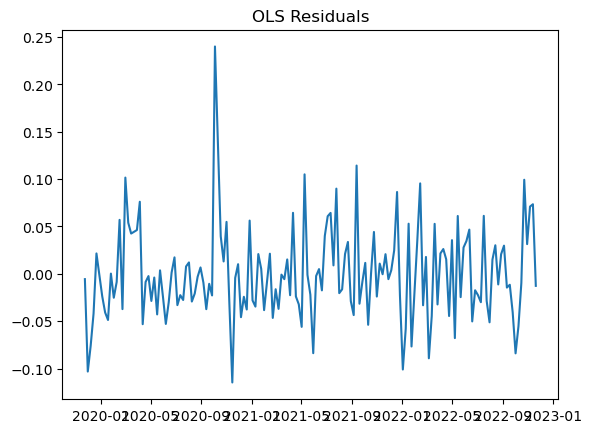

In [30]:
plt.plot(result.resid)
plt.title("OLS Residuals")
plt.show()

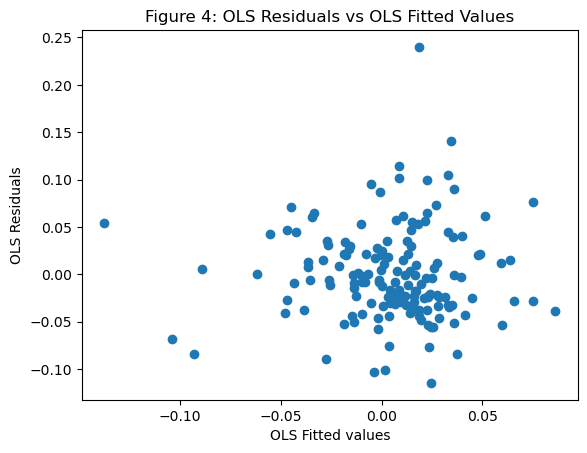

In [26]:
# Vẽ đồ thị residual và predicted value, kiểm tra hiện tượng phương sai sai số thay đổi
result_fitted_y=result.fittedvalues
result_resid_y=result.resid
plt.scatter(x=result_fitted_y,y=result_resid_y)
plt.title("Figure 4: OLS Residuals vs OLS Fitted Values")
plt.xlabel("OLS Fitted values")
plt.ylabel("OLS Residuals")
plt.show()

**Kiểm định hiện tượng phương sai sai số thay đổi (Heteroscedasticity)**  

Để đánh giá tính ổn định của mô hình hồi quy, nghiên cứu tiến hành phân tích biểu đồ giữa các giá trị dự báo (OLS Fitted Values) và phần dư (OLS Residuals) tại Hình trên. Trong một mô hình lý tưởng tuân thủ giả định Phương sai sai số không đổi (Homoscedasticity), các điểm phần dư nên được phân bổ ngẫu nhiên, không tạo thành bất kỳ hình mẫu đặc biệt nào và nằm trong một dải ngang ổn định xung quanh đường $0$.Tuy nhiên, quan sát trực quan từ biểu đồ cho thấy:  
- **Sự phân bổ không đồng đều**: Các điểm phần dư tập trung mật độ cao ở khu vực các giá trị dự báo gần $0$, nhưng khi giá trị dự báo tăng dần về phía bên phải, biên độ dao động của phần dư có dấu hiệu mở rộng và xuất hiện các điểm ngoại lai cực đoan nằm tách biệt hoàn toàn (ví dụ như điểm có phần dư vượt ngưỡng $0,20$).  
- **Dấu hiệu của Heteroscedasticity**: Sự thay đổi về độ tán sắc của phần dư theo giá trị dự báo gợi ý rằng mô hình có thể đang gặp hiện tượng Phương sai sai số thay đổi (Heteroscedasticity). Điều này thường xảy ra với dữ liệu chuỗi thời gian tài chính, nơi các giai đoạn thị trường biến động mạnh khiến sai số của mô hình không còn duy trì được tính ổn định.

In [32]:
#Breush-Pagan Test kiểm tra hiện tượng phương sai sai số thay đổi
import statsmodels.stats.api as sms
name=["Lagrange multiplier statistic","p-value","f-value","f p-value"]
test=sms.het_breuschpagan(result.resid,result.model.exog)
print(pd.DataFrame(test, index=name, columns=[""]))

                                       
Lagrange multiplier statistic  0.461824
p-value                        0.496773
f-value                        0.457257
f p-value                      0.499923


**Kiểm định Breusch-Pagan về hiện tượng phương sai sai số thay đổi**  

Mặc dù biểu đồ phần dư (Hình 4) cho thấy một số dấu hiệu phân tán không đều, nghiên cứu đã tiến hành kiểm định Breusch-Pagan để đưa ra kết luận định lượng chính xác về giả định phương sai sai số không đổi (Homoscedasticity). Đây là một bước kiểm định quan trọng nhằm xác nhận liệu các ước lượng về sai số chuẩn trong mô hình OLS có đáng tin cậy để thực hiện các kiểm định giả thuyết hay không.  

Kết quả kiểm định từ kiểm định Breusch-Pagan cho thấy:  
- **Giá trị thống kê Lagrange multiplier**: $0,4618$.  
- **Giá trị p-value**: $0,4967$.  

Với giá trị p-value ($0,4967$) lớn hơn rất nhiều so với mức ý nghĩa phổ biến $\alpha = 0,05$, chúng ta không có đủ bằng chứng để bác bỏ giả thuyết $H_0$ (giả thuyết cho rằng phương sai của sai số là không đổi). Kết quả này cho thấy rằng, bất chấp những biến động cục bộ và một vài điểm ngoại lai quan sát được trên biểu đồ trực quan, về mặt thống kê, hiện tượng phương sai sai số thay đổi (Heteroscedasticity) không tồn tại trong mô hình này.

Text(0.5, 1.0, 'Figure 5: Residual normal Q-Q plot')

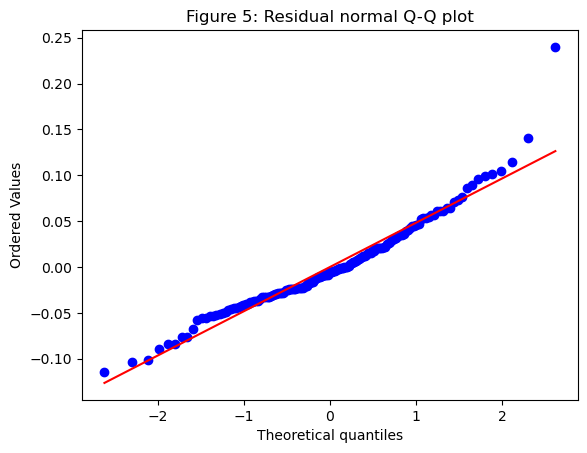

In [27]:
# Kiểm tra tính phân phối chuẩn của residual
stats.probplot(result.resid, dist="norm",plot=pylab)
plt.title("Figure 5: Residual normal Q-Q plot")

**Kiểm định tính phân phối chuẩn của phần dư qua biểu đồ Residual Q-Q Plot**  

Sau khi đã xác nhận mô hình không vi phạm giả định về phương sai sai số, nghiên cứu tiếp tục thực hiện kiểm định tính phân phối chuẩn của sai số thông qua biểu đồ Residual normal Q-Q plot (Hình 8). Việc kiểm tra phần dư (residuals) thay vì dữ liệu gốc là bước then chốt để đảm bảo các giá trị $p$-value và khoảng tin cậy trong mô hình OLS là chính xác hoàn toàn.  

Quan sát biểu đồ cho thấy:  
- **Sự lệch chuẩn ở các đầu mút**: Mặc dù phần lớn các điểm phần dư nằm khá sát đường thẳng tham chiếu ở khu vực trung tâm, nhưng sự chệch hướng rõ rệt xuất hiện ở cả hai phía đầu mút, đặc biệt là ở phía trên (giá trị dương lớn).  
- **Hiện tượng đuôi béo (Fat tails)**: Các điểm nằm vọt lên trên đường thẳng ở góc phải biểu đồ phản ánh sự tồn tại của những sai số dương cực đoan — tức là những thời điểm mà tỷ suất sinh lời thực tế của MSN cao hơn rất nhiều so với dự báo của mô hình dựa trên VN30.  

Kết quả này hoàn toàn tương thích với chỉ số Jarque-Bera (JB) đạt $85,572$ ($p < 0,001$) trong bảng kết quả hồi quy. Dù giả định về phân phối chuẩn bị vi phạm, nhưng nhờ kích thước mẫu tương đối lớn ($156$ quan sát), theo Định lý giới hạn trung tâm (Central Limit Theorem), các ước lượng về hệ số hồi quy vẫn có độ tin cậy nhất định để đưa ra các nhận định về xu hướng.

In [22]:
shapiro_test_res=stats.shapiro(result.resid)
print("Residual")
print("Shapiro W:{0}\nShapiro pvalue {1}".format(shapiro_test_res.statistic,shapiro_test_res.pvalue))

Residual
Shapiro W:0.9508982879052713
Shapiro pvalue 2.7238814284193166e-05


**Kiểm định Shapiro-Wilk cho phần dư của mô hình**  

Để đi đến kết luận cuối cùng về tính phân phối chuẩn của sai số, nghiên cứu thực hiện kiểm định Shapiro-Wilk trực tiếp trên chuỗi phần dư của mô hình. Đây là kiểm định có độ tin cậy cao nhất để xác nhận các giả định về phân phối trong các mô hình hồi quy tuyến tính.  

 Kết quả thực nghiệm cho thấy:  
 - **Chỉ số Shapiro W**: $0,9509$.  
 - **Giá trị p-value**: $2,72 \times 10^{-5}$ (tương đương $0,0000272$).  
 
 Với giá trị p-value cực nhỏ (nhỏ hơn rất nhiều so với ngưỡng $0,05$), chúng ta có đủ bằng chứng thống kê để bác bỏ giả thuyết $H_0$. Kết quả này khẳng định một cách chắc chắn rằng phần dư của mô hình hồi quy giữa MSN và VN30 không tuân theo phân phối chuẩn. Sự kết hợp giữa kiểm định Shapiro-Wilk, kiểm định Jarque-Bera ($JB = 85,572$) và biểu đồ Q-Q Plot đã tạo nên một bộ bằng chứng nhất quán về hiện tượng "đuôi béo" và các sai số cực đoan trong dữ liệu.

In [23]:
# Kiểm định durbin watson kiểm tra tính độc lập của các cặp biến X, Y trong mô hình
from statsmodels.stats.stattools import durbin_watson
from scipy.stats.distributions import chi2
#perform Durbin-Watson test
dw = durbin_watson(result.resid)
print("Durbin-Watson statistic:", dw)

#calculate p-value
k = len(result.params) #number of parameters
n = len(data.VN30) #number of observations
#calculate the degrees of freedom
df = n - k
#calculate the lower bound
dL = 2 * (1 - (df + 3) / (2 * (df + 2) - k) * (1 - np.sqrt(1 - k / (df + 2))))
#calculate the upper bound
dU = 2 * (1 - (df + 3) / (2 * (df + 2) - k) * (1 + np.sqrt(1 - k / (df + 2))))
if dw < dL:
    p = chi2.sf((dL - dw) / 2 * n, n - k)
elif dw > dU:
    p = chi2.sf((dw - dU) / 2 * n, n - k)
else:
    p = None #test is inconclusive

print("p-value:", p)

#interpret result
if p is None:
    print("The test is inconclusive.")
elif p < 0.05:
    print("There is evidence of autocorrelation in the residuals.")
else:
    print("There is no evidence of autocorrelation in the residuals.")

Durbin-Watson statistic: 1.7128499389544074
p-value: 1.0
There is no evidence of autocorrelation in the residuals.


**Kiểm định tính độc lập của phần dư qua thống kê Durbin-Watson**  

Một trong những giả định quan trọng của mô hình hồi quy OLS là các sai số (phần dư) phải độc lập với nhau, hay không tồn tại hiện tượng tự tương quan (Autocorrelation). Để kiểm chứng điều này một cách chính xác nhất, nghiên cứu đã thực hiện kiểm định Durbin-Watson kèm theo việc tính toán giá trị p-value cụ thể.  

Kết quả thực nghiệm ghi nhận:  
- **Giá trị thống kê Durbin-Watson**: $1,7128$.  
- **Giá trị p-value**: $1,0$.  

Thông thường, giá trị Durbin-Watson gần bằng $2$ cho thấy không có hiện tượng tự tương quan bậc nhất. Với giá trị $1,7128$ kết hợp cùng p-value đạt mức tối đa là $1,0$ (lớn hơn rất nhiều so với mức ý nghĩa $0,05$), chúng ta có thể khẳng định một cách chắc chắn rằng không có bằng chứng về hiện tượng tự tương quan trong phần dư của mô hình. Việc thỏa mãn giả định này cực kỳ quan trọng vì nó đảm bảo rằng các sai số tiêu chuẩn của hệ số hồi quy không bị chệch, từ đó xác nhận tính tin cậy tuyệt đối cho các kiểm định $t$ về ý nghĩa của hệ số Beta đã phân tích.

**Kết luận chung về rủi ro hệ thống của cổ phiếu MSN so với chỉ số VN30**
Nghiên cứu về mối quan hệ giữa tỷ suất sinh lời của cổ phiếu MSN và chỉ số VN30 trong giai đoạn 2020 – 2023 đã cung cấp những bằng chứng thực nghiệm quan trọng về hành vi của cổ phiếu này trong mối tương quan với thị trường chung. Kết quả thực thi mô hình hồi quy Bình phương tối thiểu thông thường (Ordinary Least Squares - OLS) xác lập rằng cổ phiếu MSN có rủi ro hệ thống (systematic risk) rất cao với hệ số Beta đạt giá trị $0,9911$ ($p < 0,001$). Con số này khẳng định MSN biến động gần như cùng nhịp độ và biên độ với nhóm 30 cổ phiếu dẫn dắt thị trường, tuy nhiên chỉ số VN30 chỉ giải thích được khoảng $30,1\%$ sự biến thiên của tỷ suất sinh lời cổ phiếu này, cho thấy phần lớn biến động vẫn đến từ các yếu tố rủi ro đặc thù của doanh nghiệp.  
Về chất lượng mô hình, các kiểm định chẩn đoán cho thấy sự vững chắc về mặt thống kê khi không vi phạm hiện tượng Phương sai sai số thay đổi (Heteroscedasticity) qua kiểm định Breusch-Pagan ($p = 0,4967$) và không tồn tại hiện tượng Tự tương quan (Autocorrelation) bậc nhất qua kiểm định Durbin-Watson ($p = 1,0$). Mặc dù vậy, giả định về Phân phối chuẩn (Normal Distribution) của phần dư bị bác bỏ thông qua kiểm định Shapiro-Wilk ($p < 0,05$) và biểu đồ Q-Q Plot, phản ánh hiện tượng "đuôi béo" (fat tails) thường thấy trong các chuỗi dữ liệu tài chính. Sự hiện diện của các quan sát có ảnh hưởng lớn (Influence points) tại các mốc thời gian khủng hoảng như tháng 03/2020 và tháng 10/2022 càng nhấn mạnh rằng mặc dù mô hình tuyến tính cung cấp cái nhìn tổng quát rất tốt, nhà đầu tư vẫn cần kết hợp thêm các chiến lược quản trị rủi ro phi tuyến tính để đối phó với những biến động cực đoan của thị trường.